<a href="https://colab.research.google.com/github/Leandro2402-bit/Analitica_de_Datos/blob/main/canales_rgb_raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de canales RGB en imágenes RAW (.dng) bajo distinta iluminación

**Objetivo:** subir 4 fotos `.dng` tomadas con el celular bajo luz **roja**, **verde**, **azul** y **blanca** (brillo máximo), extraer por separado los canales **R, G y B** de cada una y estudiar cómo cambia la intensidad de cada canal según el color de la luz.

**Nota importante sobre la decodificación:** el RAW se decodifica **sin balance de blancos** (`use_camera_wb=False`, `use_auto_wb=False`, `user_wb=[1,1,1,1]`) y **sin brillo automático** (`no_auto_bright=True`). Si el balance de blancos estuviera activo, se intentaría "corregir" el tinte de la luz y las diferencias entre canales que queremos estudiar se atenuarían o desaparecerían.

**Estructura del cuaderno**

| Celda | Contenido |
|---|---|
| 1 | Instalación de librerías e importaciones |
| 2 | Subida de las 4 fotos `.dng` |
| 3 | Etiquetado de cada foto según el color de la luz |
| 4 | Decodificación del RAW y extracción de los canales R, G, B |
| 5 | Guardado de cada canal como imagen individual |
| 6 | Visualización en escala de grises (RGB, R, G, B) |
| 7 | Visualización coloreada (solo para interpretación visual) |
| 8 | Tabla comparativa y gráfico de barras |

## Celda 1 · Instalación e importaciones

Se instala `rawpy` (envoltorio de LibRaw, permite leer y decodificar archivos RAW como `.dng`) y se importan las librerías que se usarán en el resto del cuaderno:

- `rawpy`: lectura y decodificación del RAW.
- `numpy` / `pandas`: manejo de arreglos y tablas.
- `matplotlib`: visualización.
- `cv2` (OpenCV): guardado de imágenes PNG de 16 bits.
- `google.colab.files`: subir y descargar archivos en Colab.

In [1]:
# Instalación silenciosa de rawpy (no viene preinstalado en Colab)
!pip install -q rawpy

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import rawpy
from google.colab import files

print("rawpy versión:", rawpy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 17.1 MB/s eta 0:00:00
rawpy versión: 0.27.1


## Celda 2 · Subir las 4 fotos `.dng`

Se abre el selector de archivos de Colab para subir las cuatro fotos RAW. Cada archivo se guarda en la carpeta `fotos_dng/` y luego se listan solo los que tienen extensión `.dng`.

**Recomendaciones al tomar las fotos**
- Usar el modo manual/Pro de la cámara y **fijar ISO, tiempo de exposición y enfoque**. Si el celular ajusta la exposición automáticamente, compensa parte de la diferencia de brillo entre las luces y contamina la comparación.
- Mantener la misma escena y la misma posición del celular en las cuatro tomas.
- Renombrar los archivos con el color de la luz (por ejemplo `roja.dng`, `verde.dng`, `azul.dng`, `blanca.dng`) facilita la celda 3.

In [2]:
CARPETA_FOTOS = "fotos_dng"
os.makedirs(CARPETA_FOTOS, exist_ok=True)

# Abre el selector de archivos; devuelve un diccionario {nombre: bytes}
subidos = files.upload()

# Guardar cada archivo subido dentro de la carpeta de trabajo
for nombre, contenido in subidos.items():
    with open(os.path.join(CARPETA_FOTOS, nombre), "wb") as f:
        f.write(contenido)

# Quedarse solo con los .dng (sin importar mayúsculas/minúsculas)
archivos = sorted(
    os.path.join(CARPETA_FOTOS, n)
    for n in os.listdir(CARPETA_FOTOS)
    if n.lower().endswith(".dng")
)

print(f"Archivos .dng encontrados: {len(archivos)}")
for a in archivos:
    print("  -", a)

if len(archivos) != 4:
    print("\n⚠️ Se esperaban exactamente 4 fotos .dng. Revisa los archivos subidos.")

Saving azul.dng to azul.dng
Saving rojo.dng to rojo.dng
Saving verde.dng to verde.dng
Saving brillomax.dng to brillomax.dng
Archivos .dng encontrados: 4
  - fotos_dng/azul.dng
  - fotos_dng/brillomax.dng
  - fotos_dng/rojo.dng
  - fotos_dng/verde.dng


## Celda 3 · Etiquetar cada foto según el color de la luz

Se detecta **automáticamente** el color de la luz a partir de palabras clave en el nombre del archivo (por ejemplo `roja`, `red`, `verde`, `green`, `azul`, `blue`, `blanca`, `white`, `brillo`).

El resultado se guarda en el diccionario `ETIQUETAS` con la forma `{"roja": ruta, ...}` y se imprime al final de la celda. **Si alguna foto no se reconoce**, ajusta manualmente el diccionario `ETIQUETAS` (hay un ejemplo comentado en el código).

In [3]:
# Orden fijo en el que se procesarán y mostrarán las fotos
ORDEN = ["roja", "verde", "azul", "blanca"]

# Palabras clave (en minúsculas) que identifican cada condición de luz
PALABRAS_CLAVE = {
    "roja":   ["roja", "rojo", "red"],
    "verde":  ["verde", "green"],
    "azul":   ["azul", "blue"],
    "blanca": ["blanca", "blanco", "white", "brillo", "max"],
}

# Detección automática: se asigna cada archivo a la primera etiqueta que coincida
ETIQUETAS = {}
for ruta in archivos:
    nombre = os.path.basename(ruta).lower()
    for etiqueta, palabras in PALABRAS_CLAVE.items():
        if any(p in nombre for p in palabras):
            ETIQUETAS[etiqueta] = ruta
            break

# --- AJUSTE MANUAL (descomenta y edita si la detección automática falla) ---
# ETIQUETAS = {
#     "roja":   "fotos_dng/IMG_0001.dng",
#     "verde":  "fotos_dng/IMG_0002.dng",
#     "azul":   "fotos_dng/IMG_0003.dng",
#     "blanca": "fotos_dng/IMG_0004.dng",
# }

print("ETIQUETAS =")
for etiqueta in ORDEN:
    print(f"  {etiqueta:7s} -> {ETIQUETAS.get(etiqueta, '❌ NO RECONOCIDA')}")

faltan = [e for e in ORDEN if e not in ETIQUETAS]
if faltan:
    raise ValueError(f"Faltan etiquetas por asignar: {faltan}. Ajusta el diccionario ETIQUETAS.")

ETIQUETAS =
  roja    -> fotos_dng/rojo.dng
  verde   -> fotos_dng/verde.dng
  azul    -> fotos_dng/azul.dng
  blanca  -> fotos_dng/brillomax.dng


## Celda 4 · Decodificar el RAW y extraer los canales R, G, B

Se decodifica cada `.dng` con `raw.postprocess(...)` usando parámetros que **evitan cualquier corrección de color o brillo**, ya que el objetivo es observar los datos tal como los captó el sensor:

| Parámetro | Valor | Motivo |
|---|---|---|
| `use_camera_wb` | `False` | No aplicar el balance de blancos guardado por el celular |
| `use_auto_wb` | `False` | No estimar un balance de blancos automático |
| `user_wb` | `[1, 1, 1, 1]` | Multiplicadores neutros. Sin esto, LibRaw aplicaría por defecto multiplicadores de "luz de día" |
| `no_auto_bright` | `True` | No reescalar el brillo automáticamente |
| `gamma` | `(1, 1)` | Mantener valores **lineales** (sin curva gamma), para que la intensidad sea proporcional a la luz captada |
| `output_bps` | `16` | Salida de 16 bits (valores de 0 a 65535), sin perder información |
| `output_color` | `raw` | No convertir al espacio de color sRGB |

Después se separan los tres canales de cada imagen y se guardan en el diccionario `CANALES`.

In [4]:
MAXVAL = 65535  # valor máximo con 16 bits por canal

IMAGENES = {}   # {etiqueta: imagen RGB completa (alto x ancho x 3)}
CANALES = {}    # {etiqueta: {"R": matriz, "G": matriz, "B": matriz}}

for etiqueta in ORDEN:
    with rawpy.imread(ETIQUETAS[etiqueta]) as raw:
        rgb = raw.postprocess(
            use_camera_wb=False,                    # sin balance de blancos de la cámara
            use_auto_wb=False,                      # sin balance de blancos automático
            user_wb=[1, 1, 1, 1],                   # multiplicadores neutros (R, G, B, G2)
            no_auto_bright=True,                    # sin brillo automático
            gamma=(1, 1),                           # respuesta lineal (sin gamma)
            output_bps=16,                          # 16 bits por canal
            output_color=rawpy.ColorSpace.raw,      # sin conversión a sRGB
        )

    IMAGENES[etiqueta] = rgb
    # Canal 0 = R, canal 1 = G, canal 2 = B (cada uno es una matriz 2D en escala de grises)
    CANALES[etiqueta] = {"R": rgb[:, :, 0], "G": rgb[:, :, 1], "B": rgb[:, :, 2]}

    print(f"{etiqueta:7s} | forma: {rgb.shape} | tipo: {rgb.dtype} | "
          f"mín: {rgb.min()} | máx: {rgb.max()}")

roja    | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
verde   | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
azul    | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535
blanca  | forma: (4096, 3072, 3) | tipo: uint16 | mín: 0 | máx: 65535


## Celda 5 · Guardar cada componente como imagen individual

Cada canal se guarda como un **PNG en escala de grises de 16 bits** dentro de la carpeta `canales_guardados/`, con nombres del tipo `roja_R.png`, `roja_G.png`, `roja_B.png`, etc. (12 archivos en total).

Al guardar en 16 bits se conserva toda la información original: el valor de cada píxel es directamente la intensidad de ese canal (0 = negro, 65535 = blanco), sin ningún color agregado.

Al final hay una línea comentada para descargar todo en un `.zip`.

In [5]:
SALIDA = "canales_guardados"
os.makedirs(SALIDA, exist_ok=True)

for etiqueta in ORDEN:
    for canal, matriz in CANALES[etiqueta].items():
        ruta_png = os.path.join(SALIDA, f"{etiqueta}_{canal}.png")
        # OpenCV guarda uint16 como PNG de 16 bits sin pérdida
        cv2.imwrite(ruta_png, matriz)

print("Archivos guardados:")
for n in sorted(os.listdir(SALIDA)):
    print("  -", n)

# Para descargar todos los canales en un solo .zip, descomenta estas dos líneas:
# shutil.make_archive("canales_guardados", "zip", SALIDA)
# files.download("canales_guardados.zip")

Archivos guardados:
  - azul_B.png
  - azul_G.png
  - azul_R.png
  - blanca_B.png
  - blanca_G.png
  - blanca_R.png
  - roja_B.png
  - roja_G.png
  - roja_R.png
  - verde_B.png
  - verde_G.png
  - verde_R.png


## Celda 6 · Ver los 3 canales de cada foto en escala de grises

Cada **fila** es una foto (una condición de luz) y las **columnas** son: RGB completo, canal R, canal G y canal B.

Los 3 canales se muestran en escala de grises (`cmap="gray"`), igual que se guardaron en la celda 5: el brillo de cada píxel es directamente el valor de intensidad de ese canal (0 = negro, 65535 = blanco), **sin ningún color agregado**.

**Detalles importantes para que la comparación sea justa**
- Se fijan `vmin=0` y `vmax=1` (valores normalizados) en **todas** las imágenes. Si no se hiciera, `imshow` reescalaría cada panel a su propio mínimo y máximo, y un canal débil se vería igual de brillante que uno fuerte.
- Para no saturar la memoria de Colab, solo se muestra 1 de cada `PASO` píxeles (submuestreo) y solo para visualizar. Los cálculos y los archivos guardados usan la resolución completa.
- Como los datos son lineales, las imágenes pueden verse oscuras. Si quieres aclararlas **igual en todos los paneles**, sube `GAMMA_VISUAL` a `2.2`. Es solo un ajuste visual.

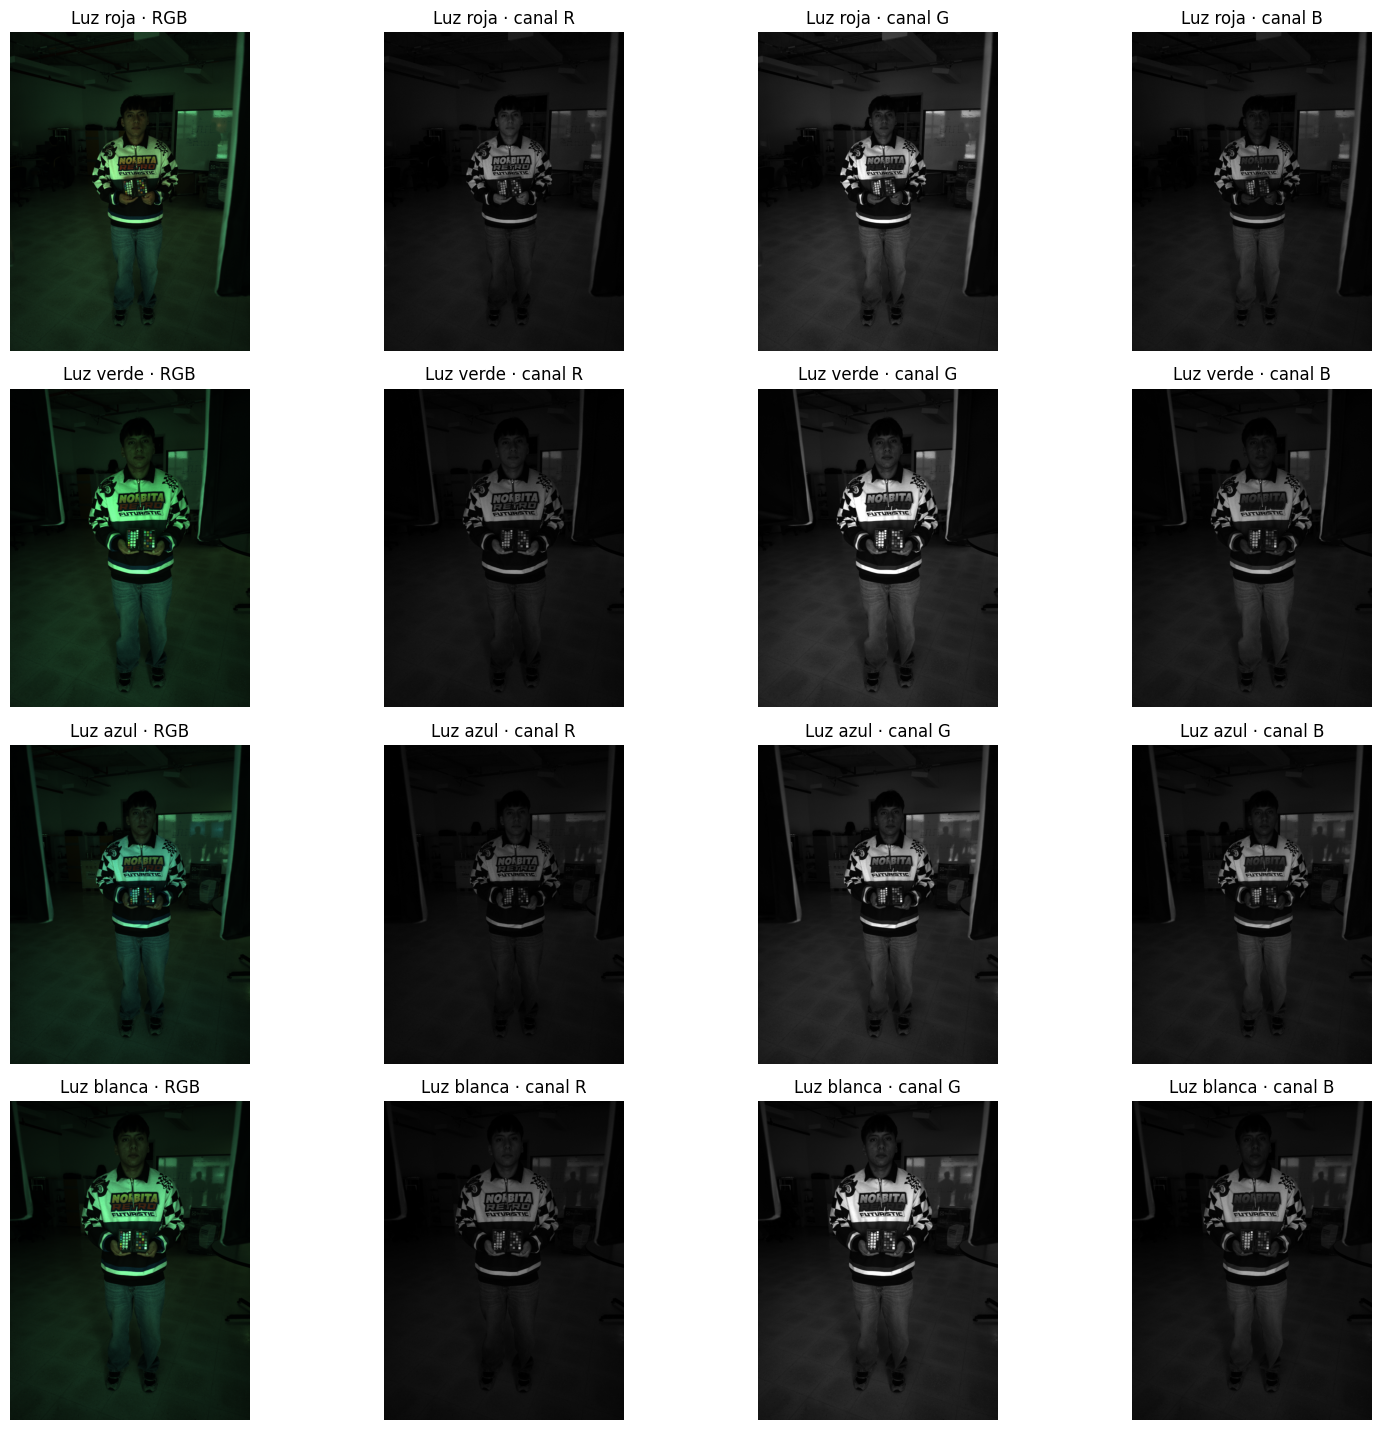

In [6]:
PASO = 4             # submuestreo solo para mostrar (1 de cada 4 píxeles)
GAMMA_VISUAL = 1.0   # 1.0 = lineal (fiel a los datos); 2.2 = aclara solo para ver

def preparar(matriz):
    # Normaliza a [0, 1] y submuestrea; la escala es idéntica para todas las imágenes
    x = matriz[::PASO, ::PASO].astype(np.float32) / MAXVAL
    return np.clip(x, 0, 1) ** (1 / GAMMA_VISUAL)

fig, ejes = plt.subplots(len(ORDEN), 4, figsize=(16, 3.6 * len(ORDEN)))

for i, etiqueta in enumerate(ORDEN):
    # Columna 0: imagen RGB completa
    ejes[i, 0].imshow(preparar(IMAGENES[etiqueta]))
    ejes[i, 0].set_title(f"Luz {etiqueta} · RGB")

    # Columnas 1-3: cada canal en escala de grises con escala fija (vmin/vmax)
    for j, canal in enumerate(["R", "G", "B"], start=1):
        ejes[i, j].imshow(preparar(CANALES[etiqueta][canal]), cmap="gray", vmin=0, vmax=1)
        ejes[i, j].set_title(f"Luz {etiqueta} · canal {canal}")

for ax in ejes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

## Celda 7 · Vista coloreada (solo para interpretar más fácil en pantalla)

Esta celda es **puramente visual**: colorea cada canal con su color correspondiente (R en rojo, G en verde, B en azul) para que sea más intuitivo comparar a simple vista cuál canal domina en cada foto.

**No cambia ni reemplaza** los archivos en escala de grises guardados en la celda 5: es solo otra forma de mirar los mismos datos. Se mantiene la misma escala fija que en la celda 6.

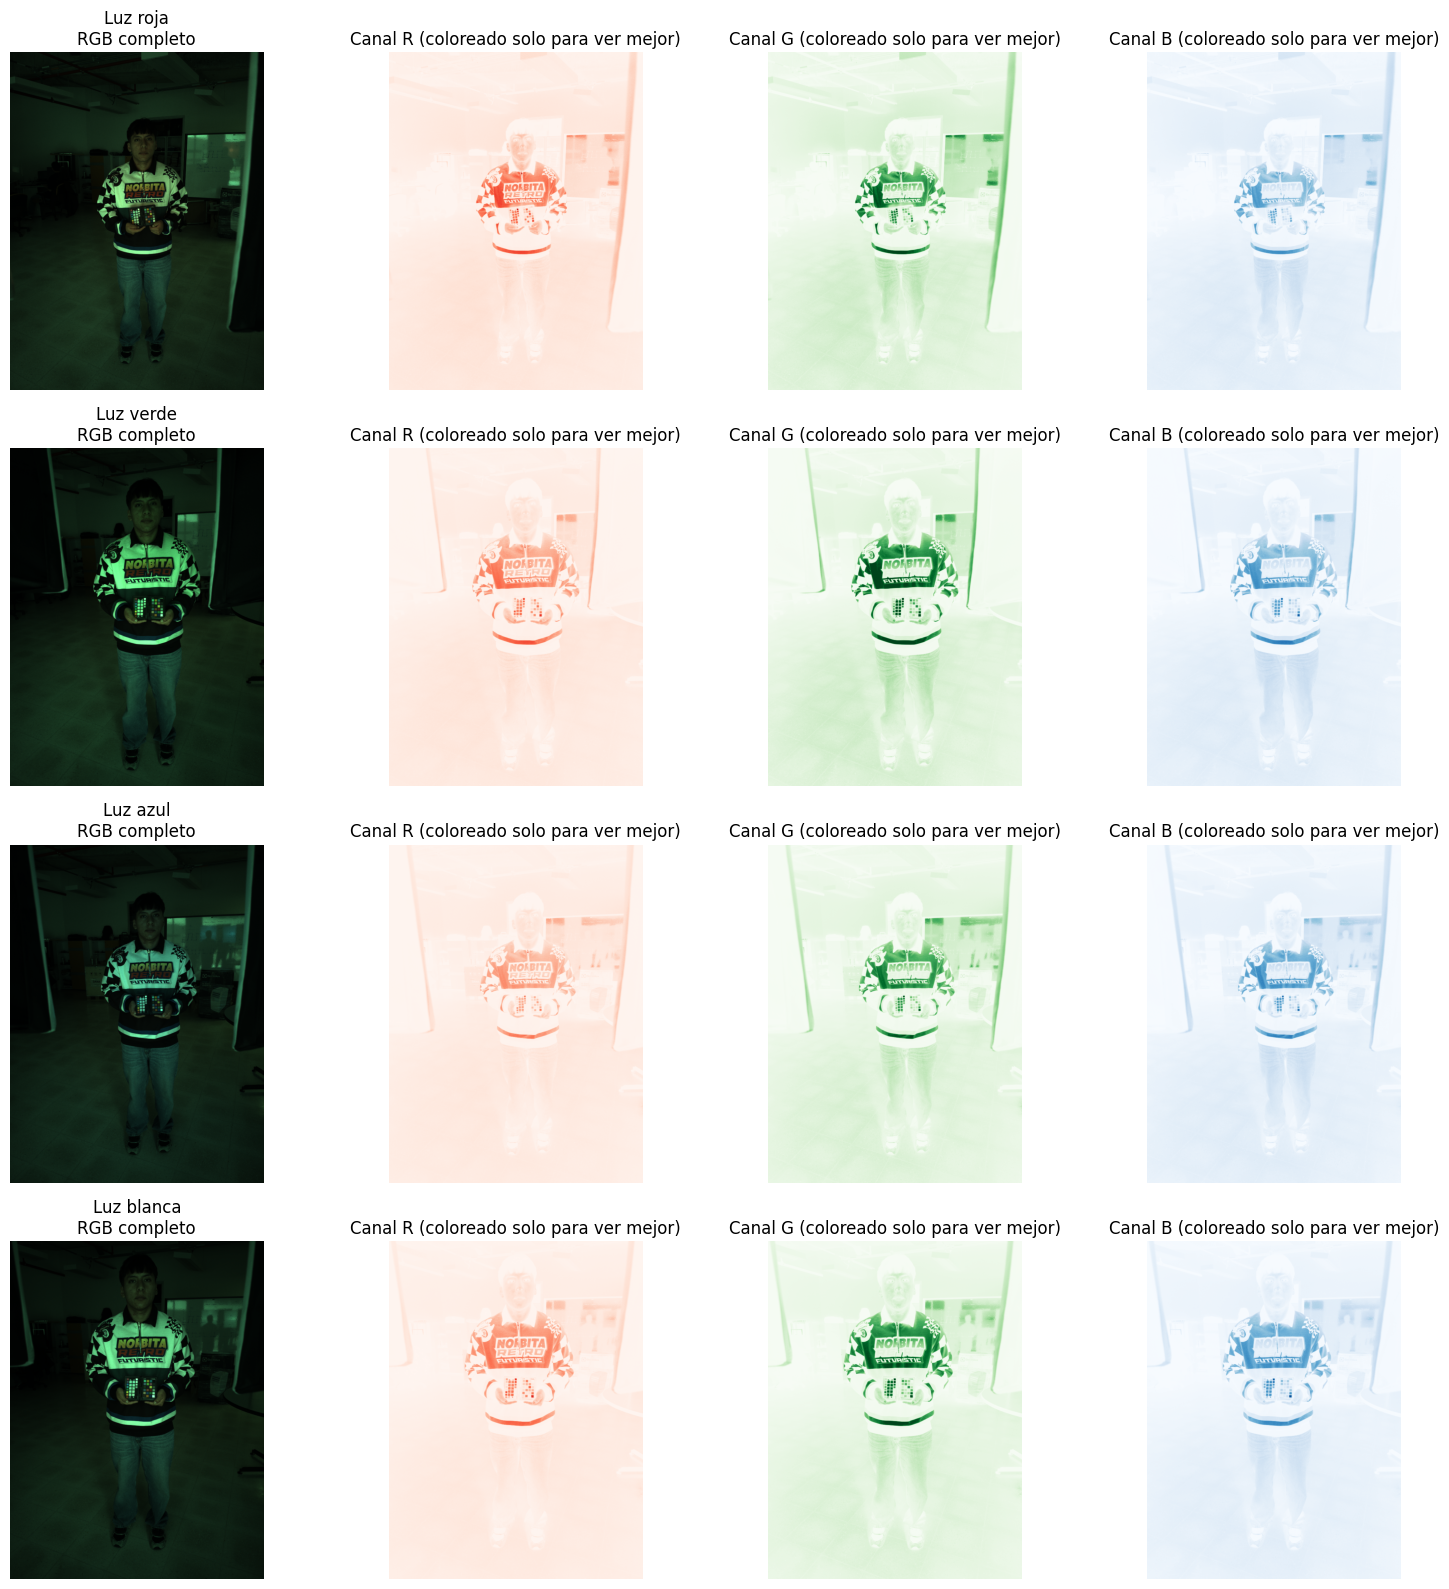

In [9]:
n = len(ORDEN)   # número de fotos (filas de la figura)

fig, axs = plt.subplots(n, 4, figsize=(16, 4 * n))
if n == 1:
    axs = axs[None, :]   # garantiza que axs siempre sea 2D, aunque haya una sola foto

# Mapa de color de cada canal (solo para ver mejor en pantalla)
CMAPS = {"R": "Reds", "G": "Greens", "B": "Blues"}

for i, etiqueta in enumerate(ORDEN):
    # Columna 0: imagen RGB completa
    axs[i, 0].imshow(preparar(IMAGENES[etiqueta]))
    axs[i, 0].set_title(f"Luz {etiqueta}\nRGB completo")
    axs[i, 0].axis("off")

    # Columnas 1-3: cada canal con su mapa de color y escala fija (vmin/vmax)
    for j, canal in enumerate(["R", "G", "B"], start=1):
        axs[i, j].imshow(preparar(CANALES[etiqueta][canal]),
                         cmap=CMAPS[canal], vmin=0, vmax=1)
        axs[i, j].set_title(f"Canal {canal} (coloreado solo para ver mejor)")
        axs[i, j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SALIDA, "comparacion_canales_coloreada.png"), dpi=120, bbox_inches="tight")
plt.show()

## Celda 8 · Tabla comparativa y gráfico de barras

Se calcula, con la **resolución completa** de cada imagen, la intensidad **media** y **mediana** de cada canal para cada condición de luz, además del **porcentaje que aporta cada canal** al total (`R / (R+G+B)`, etc.), que hace evidente cuál canal domina.

Se muestran dos gráficos de barras agrupadas: la intensidad media por canal y el aporte porcentual de cada canal, para cada tipo de luz.

**Cómo interpretarlo:** con luz roja se espera que R domine claramente sobre G y B; con luz verde, G; con luz azul, B; y con luz blanca los tres canales deberían tener valores altos y relativamente parecidos (las diferencias residuales se deben a la respuesta del sensor y a que no se aplicó balance de blancos).

,Media R,Mediana R,Media G,Mediana G,Media B,Mediana B,% R,% G,% B
Luz,,,,,,,,,
roja,4976.3,4386.0,9115.9,8464.0,5609.4,5051.0,25.3,46.3,28.5
verde,4128.9,3686.0,9070.2,8123.0,5414.2,4663.0,22.2,48.7,29.1
azul,3722.1,3515.0,8134.9,7713.0,5581.7,4914.0,21.3,46.6,32.0
blanca,4067.5,3413.0,8451.3,7236.0,5351.0,4334.0,22.8,47.3,29.9


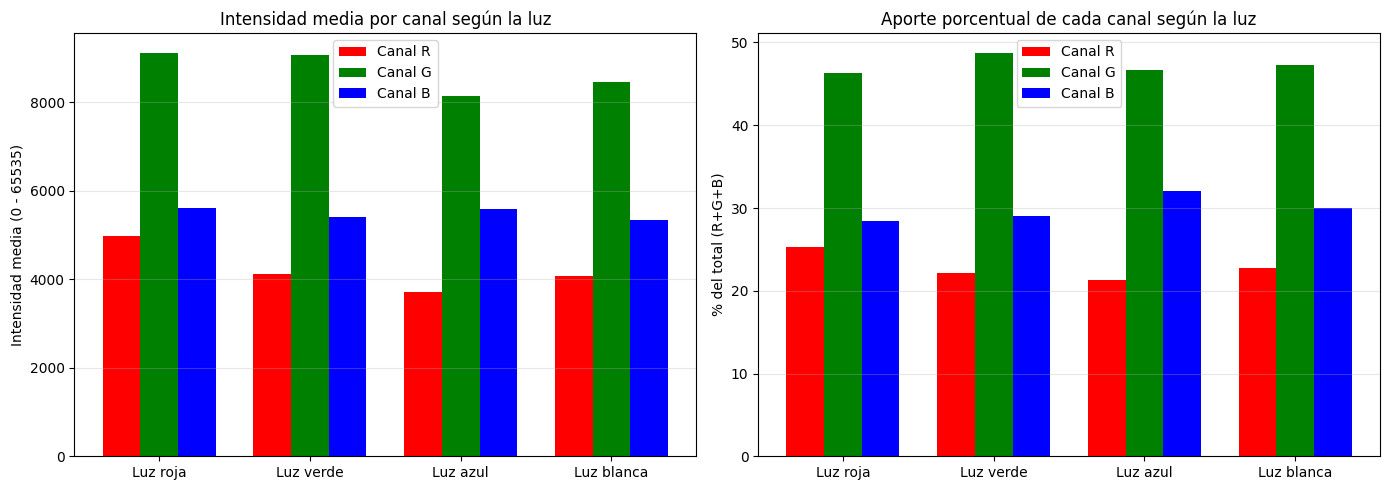

In [8]:
# ---- Tabla con media y mediana de cada canal (resolución completa) ----
filas = []
for etiqueta in ORDEN:
    fila = {"Luz": etiqueta}
    medias = {}
    for canal in ["R", "G", "B"]:
        datos = CANALES[etiqueta][canal]
        medias[canal] = float(datos.mean())
        fila[f"Media {canal}"] = medias[canal]
        fila[f"Mediana {canal}"] = float(np.median(datos))
    total = sum(medias.values())
    for canal in ["R", "G", "B"]:
        fila[f"% {canal}"] = 100 * medias[canal] / total   # aporte del canal al total
    filas.append(fila)

tabla = pd.DataFrame(filas).set_index("Luz")
display(tabla.round(1))

# ---- Gráficos de barras agrupadas ----
colores_barras = {"R": "red", "G": "green", "B": "blue"}
x = np.arange(len(ORDEN))
ancho = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for k, canal in enumerate(["R", "G", "B"]):
    ax1.bar(x + (k - 1) * ancho, tabla[f"Media {canal}"], ancho,
            label=f"Canal {canal}", color=colores_barras[canal])
    ax2.bar(x + (k - 1) * ancho, tabla[f"% {canal}"], ancho,
            label=f"Canal {canal}", color=colores_barras[canal])

ax1.set_title("Intensidad media por canal según la luz")
ax1.set_ylabel("Intensidad media (0 - 65535)")
ax2.set_title("Aporte porcentual de cada canal según la luz")
ax2.set_ylabel("% del total (R+G+B)")

for ax in (ax1, ax2):
    ax.set_xticks(x)
    ax.set_xticklabels([f"Luz {e}" for e in ORDEN])
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()